In [3]:
import pandas as pd

df = pd.read_csv("developer_dataset.csv")

print(df.columns)

C:\Users\Nicolas\AppData\Local\Temp\ipykernel_15424\3808710513.py:3: DtypeWarning: Columns (0: NEWJobHunt, 1: NEWJobHuntResearch, 2: NEWLearn) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("developer_dataset.csv")


Index(['RespondentID', 'Year', 'Country', 'Employment', 'UndergradMajor',
       'DevType', 'LanguageWorkedWith', 'LanguageDesireNextYear',
       'DatabaseWorkedWith', 'DatabaseDesireNextYear', 'PlatformWorkedWith',
       'PlatformDesireNextYear', 'Hobbyist', 'OrgSize', 'YearsCodePro',
       'JobSeek', 'ConvertedComp', 'WorkWeekHrs', 'NEWJobHunt',
       'NEWJobHuntResearch', 'NEWLearn'],
      dtype='str')


In [4]:
df.count()

RespondentID              111209
Year                      111209
Country                   111209
Employment                109425
UndergradMajor             98453
DevType                   100433
LanguageWorkedWith        102018
LanguageDesireNextYear     96044
DatabaseWorkedWith         85859
DatabaseDesireNextYear     74234
PlatformWorkedWith         91609
PlatformDesireNextYear     85376
Hobbyist                   68352
OrgSize                    54804
YearsCodePro               94793
JobSeek                    60556
ConvertedComp              91333
WorkWeekHrs                51089
NEWJobHunt                 19127
NEWJobHuntResearch         18683
NEWLearn                   24226
dtype: int64

In [5]:
df.describe()

,RespondentID,Year,YearsCodePro,ConvertedComp,WorkWeekHrs
count,111209.000000,111209.000000,94793.000000,9.133300e+04,51089.000000
mean,19262.039709,2018.854832,9.547045,1.251777e+05,41.051670
std,11767.011322,0.777503,7.548931,2.461218e+05,13.833929
min,1.000000,2018.000000,0.000000,0.000000e+00,1.000000
25%,9268.000000,2018.000000,4.000000,4.600000e+04,40.000000
50%,18535.000000,2019.000000,8.000000,7.900000e+04,40.000000
75%,28347.000000,2019.000000,14.000000,1.200000e+05,42.000000
max,42857.000000,2020.000000,50.000000,2.000000e+06,475.000000


In [6]:
maxRows = df["RespondentID"].count()

print("% Missing Data:")
print((1 - df.count() / maxRows) * 100)

% Missing Data:
RespondentID               0.000000
Year                       0.000000
Country                    0.000000
Employment                 1.604187
UndergradMajor            11.470295
DevType                    9.689863
LanguageWorkedWith         8.264619
LanguageDesireNextYear    13.636486
DatabaseWorkedWith        22.794918
DatabaseDesireNextYear    33.248208
PlatformWorkedWith        17.624473
PlatformDesireNextYear    23.229235
Hobbyist                  38.537349
OrgSize                   50.719816
YearsCodePro              14.761395
JobSeek                   45.547573
ConvertedComp             17.872654
WorkWeekHrs               54.060373
NEWJobHunt                82.800852
NEWJobHuntResearch        83.200101
NEWLearn                  78.215792
dtype: float64


In [7]:
df.drop(["NEWJobHunt", "NEWJobHuntResearch", "NEWLearn"], axis = 1, inplace = True)

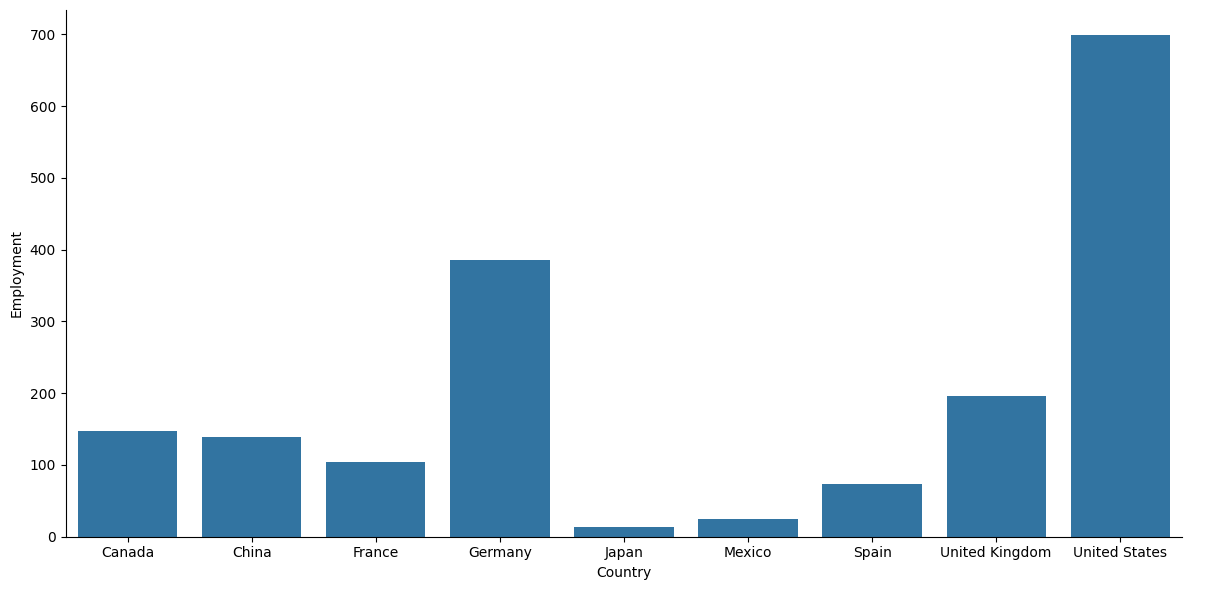

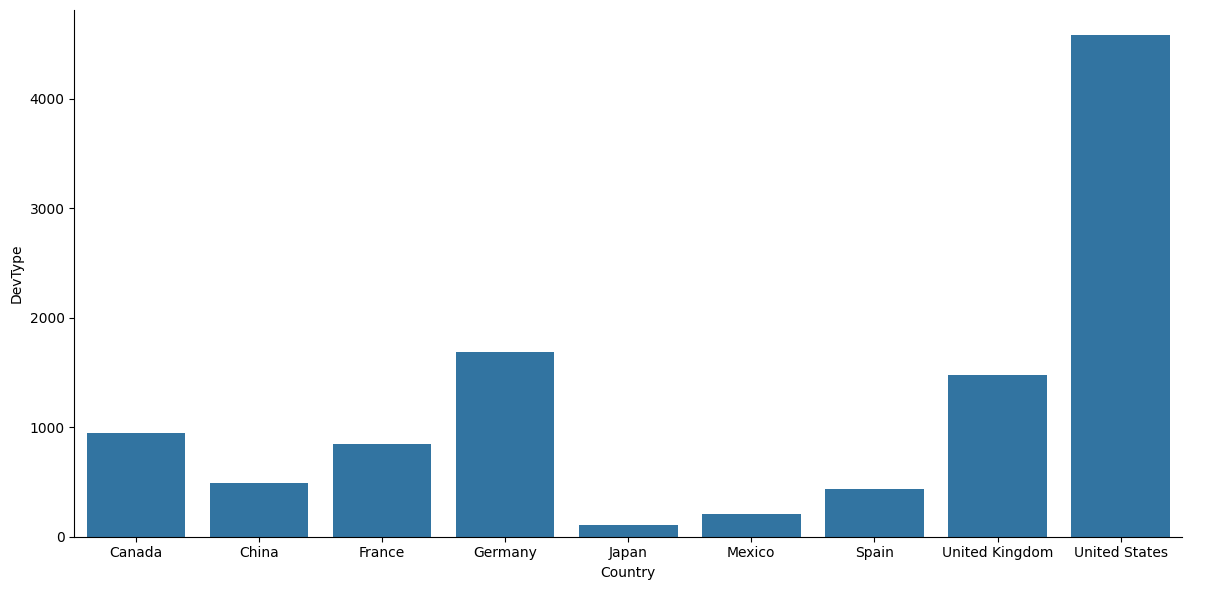

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df[["RespondentID", "Country"]].groupby("Country").count()

missingData = df[["Employment", "DevType"]].isnull().groupby(df["Country"]).sum().reset_index()

A=sns.catplot(
    data = missingData,
    kind = "bar",
    x = "Country",
    y = "Employment",
    height = 6,
    aspect = 2
)
B=sns.catplot(
    data = missingData,
    kind = "bar",
    x = "Country",
    y = "DevType",
    height = 6,
    aspect = 2
)

In [9]:
df.dropna(subset = ["Employment", "DevType"],
          inplace = True,
          how = "any")

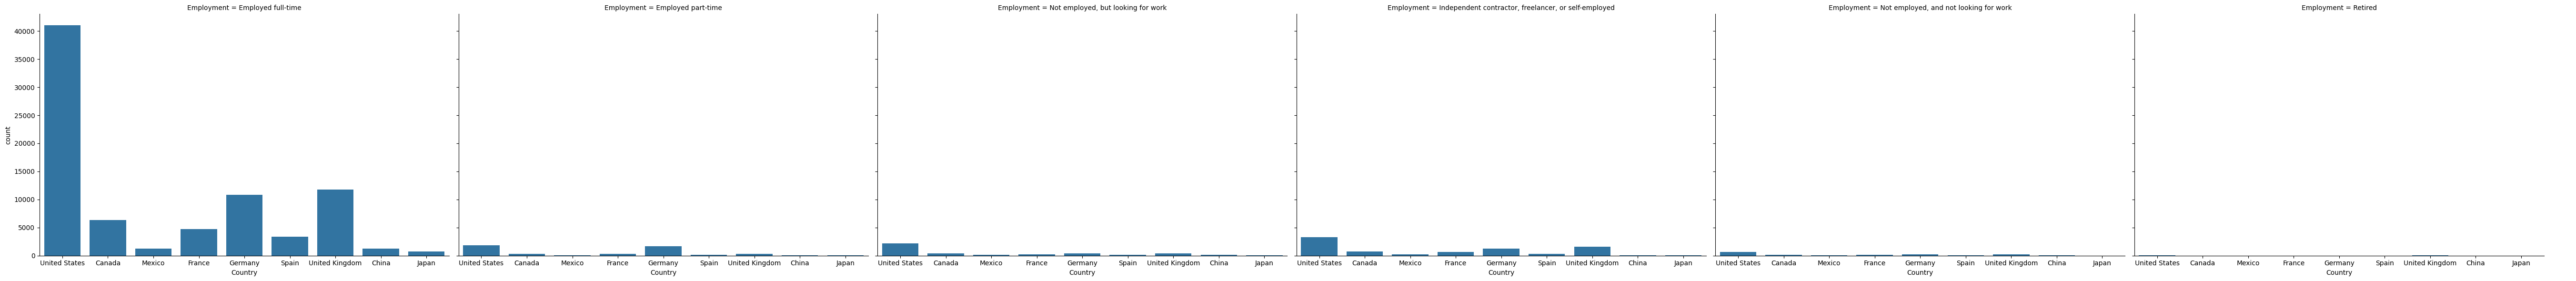

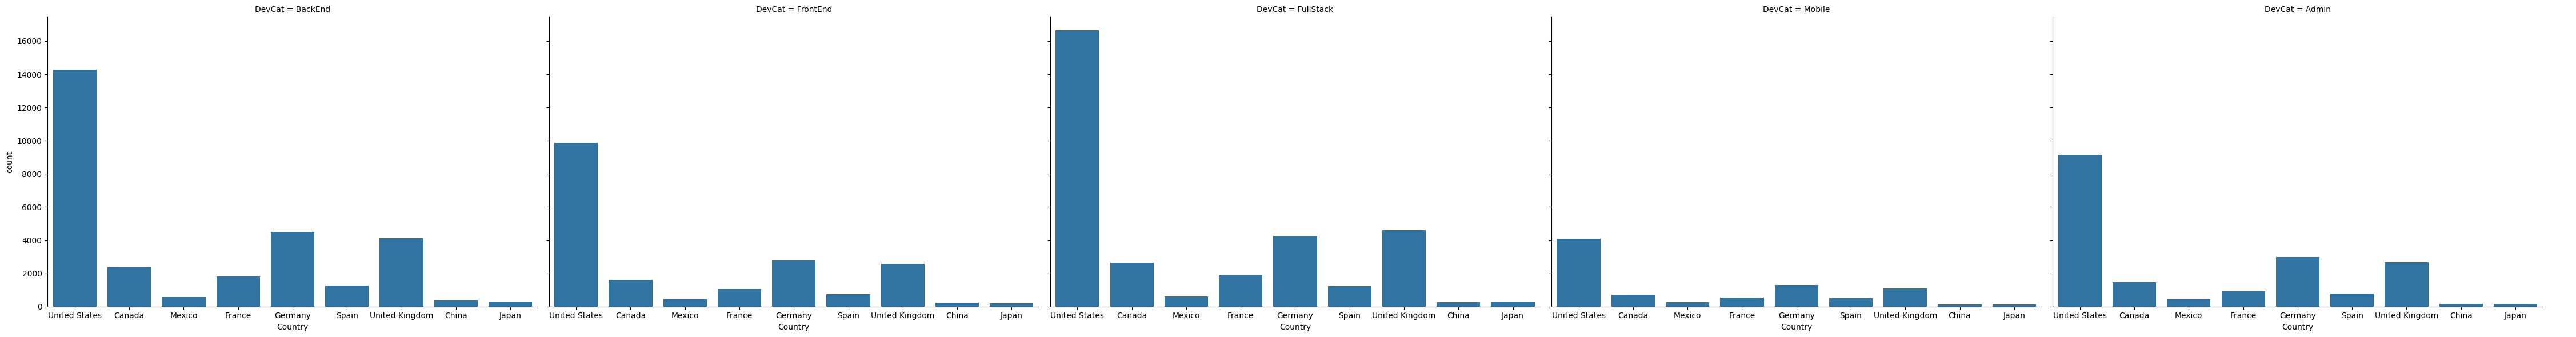

In [10]:
empfig = sns.catplot(
    x = "Country",
    col = "Employment",
    data = df,
    kind = "count",
    height = 6,
    aspect = 1.5
)

devdf = df[["Country", "DevType"]]
devdf.loc[devdf["DevType"].str.contains("back-end"), "BackEnd"] = True
devdf.loc[devdf["DevType"].str.contains("front-end"), "FrontEnd"] = True
devdf.loc[devdf["DevType"].str.contains("full-stack"), "FullStack"] = True
devdf.loc[devdf["DevType"].str.contains("mobile"), "Mobile"] = True
devdf.loc[devdf["DevType"].str.contains("administrator"), "Admin"] = True

devdf = devdf.melt(id_vars = ["Country"],
                   value_vars = ["BackEnd", "FrontEnd", "FullStack", "Mobile", "Admin"],
                   var_name = "DevCat",
                   value_name = "DevFlag")

devdf.dropna(how = "any", inplace = True)

devFig = sns.catplot(
    x = "Country",
    col = "DevCat",
    data = devdf,
    kind = "count",
    height = 6,
    aspect = 1.5
)

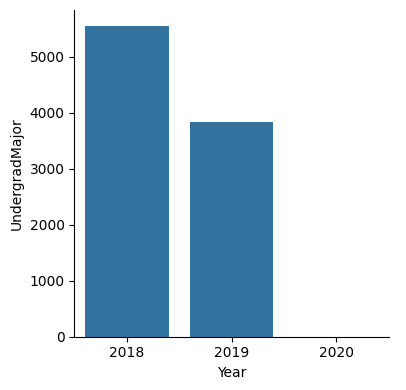

In [11]:
missingUndergrad = df["UndergradMajor"].isnull().groupby(df["Year"]).sum().reset_index()

sns.catplot(x = "Year",
            y = "UndergradMajor",
            data = missingUndergrad,
            kind = "bar",
            height = 4,
            aspect = 1);

In [12]:
df = df.sort_values(["RespondentID", "Year"])

df["UndergradMajor"].bfill(axis = 0, inplace = True)

C:\Users\Nicolas\AppData\Local\Temp\ipykernel_15424\795212694.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["UndergradMajor"].bfill(axis = 0, inplace = True)


0         Computer science, computer engineering, or sof...
1         Computer science, computer engineering, or sof...
3         Computer science, computer engineering, or sof...
4         Computer science, computer engineering, or sof...
5         Computer science, computer engineering, or sof...
                                ...                        
111187    Computer science, computer engineering, or sof...
111188    Computer science, computer engineering, or sof...
111190    A humanities discipline (ex. literature, histo...
111191                                                  NaN
111198                                                  NaN
Name: UndergradMajor, Length: 99975, dtype: str

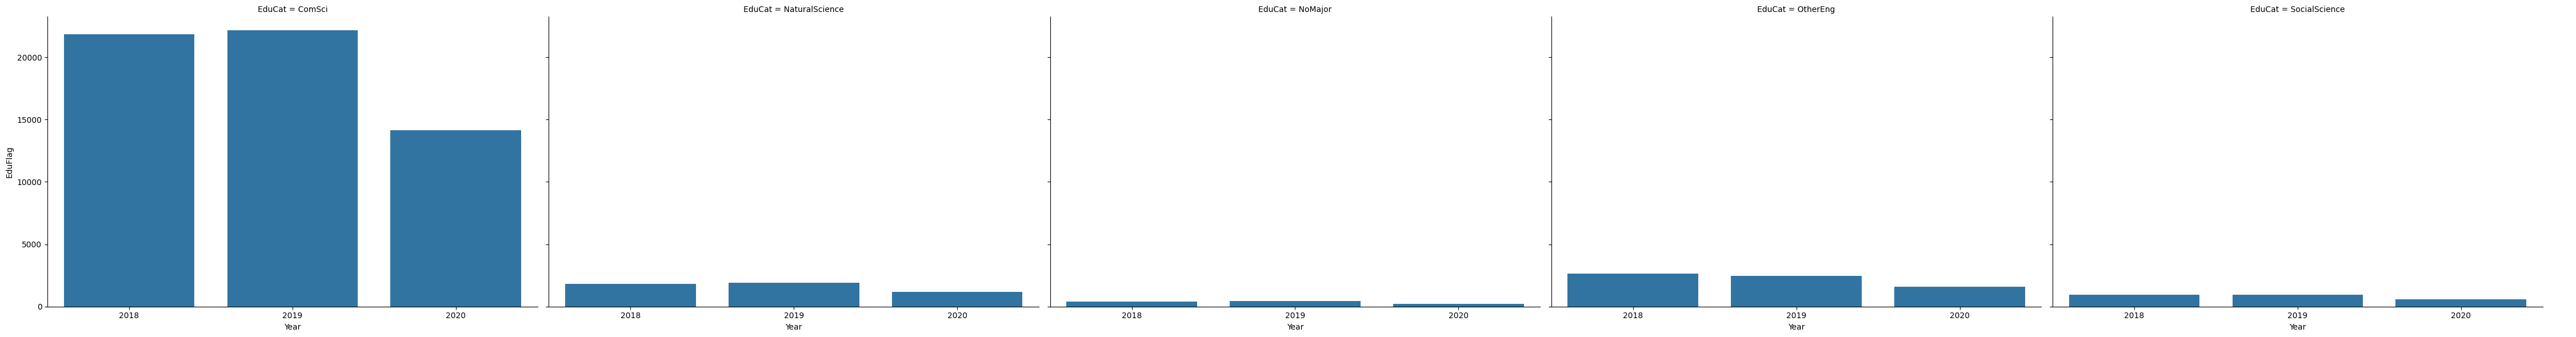

In [13]:
majors = ["social science", "natural science", "computer science", "development", "another engineering", "never declared"]

edudf = df[["Year", "UndergradMajor"]]
edudf.dropna(how = "any", inplace = True)
edudf.loc[edudf["UndergradMajor"].str.contains("(?i)social science"), "SocialScience"] = True
edudf.loc[edudf["UndergradMajor"].str.contains("(?i)natural science"), "NaturalScience"] = True
edudf.loc[edudf["UndergradMajor"].str.contains("(?i)computer science"), "ComSci"] = True
edudf.loc[edudf["UndergradMajor"].str.contains("(?i)development"), "ComSci"] = True
edudf.loc[edudf["UndergradMajor"].str.contains("(?i)another engineering"), "OtherEng"] = True
edudf.loc[edudf["UndergradMajor"].str.contains("(?i)never declared"), "NoMajor"] = True

edudf = edudf.melt(id_vars = ["Year"],
                  value_vars = ["SocialScience", "NaturalScience", "ComSci", "OtherEng", "NoMajor"],
                  var_name = "EduCat",
                  value_name = "EduFlag")

edudf.dropna(how = "any", inplace = True)
edudf = edudf.groupby(["Year", "EduCat"]).count().reset_index()

eduFig = sns.catplot(x = "Year",
                     y = "EduFlag",
                     col = "EduCat",
                     data = edudf,
                     kind = "bar",
                     height = 6,
                     aspect = 1.5);

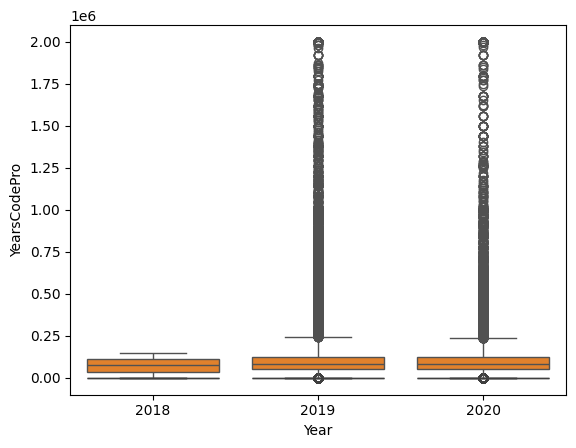

In [14]:
compFields = df[["Year", "YearsCodePro", "ConvertedComp"]]

D = sns.boxplot(x = "Year",
                y = "YearsCodePro",
                data = compFields)

E = sns.boxplot(x = "Year",
                y = "ConvertedComp",
                data = compFields)

In [16]:
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split

imputedf = df[["YearsCodePro", "ConvertedComp"]]

traindf, testdf = train_test_split(imputedf, train_size = 0.1)

imp = IterativeImputer(max_iter = 20, random_state = 0)

imp.fit(imputedf)

compdf = pd.DataFrame(np.round(imp.transform(imputedf), 0),
columns = ["YearsCodePro", "ConvertedComp"])

<Axes: xlabel='CodeYearBins', ylabel='ConvertedComp'>

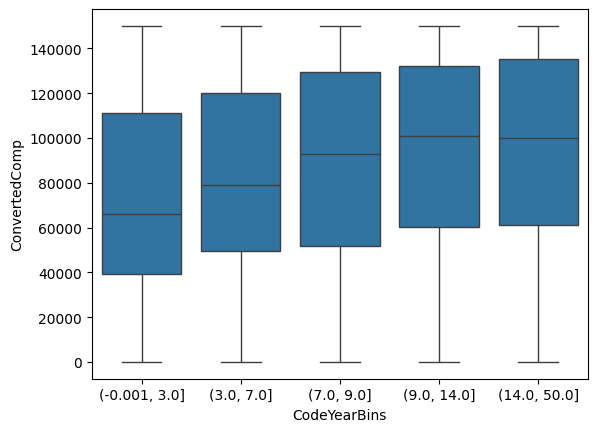

In [19]:
compPlotdf = compdf.loc[compdf["ConvertedComp"] <= 150000]
compPlotdf["CodeYearBins"] = pd.qcut(compPlotdf["YearsCodePro"], q = 5)

sns.boxplot(x = "CodeYearBins",
            y = "ConvertedComp",
            data = compPlotdf)